<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv("../data/data.csv")

# Display the first few rows of the dataset
df.head()


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,0,0,0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,2,2,2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,3,3,3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,4,4,4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [2]:
# df.to_csv("data.csv")

### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [3]:
## Write your code here
df.describe()

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65457.000000,65457.000000,65457.000000,65457.000000,3.374400e+04,29664.000000,29330.000000,29399.000000,29417.000000,29456.000000,29454.000000,29462.000000,29462.000000,29456.000000,29451.000000,2.343700e+04,29131.000000
mean,32728.000000,32728.000000,32728.000000,32714.493591,2.963490e+145,11.466323,18.578998,7.520604,10.059485,24.339971,22.964277,20.279127,16.167837,10.953481,9.953618,8.615893e+04,6.934915
std,18895.952622,18895.952622,18895.952622,18892.431636,5.443794e+147,9.168205,25.965347,18.421094,21.831924,27.088870,27.017634,26.110706,24.844177,22.904463,21.775070,1.867532e+05,2.088356
min,0.000000,0.000000,0.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16364.000000,16364.000000,16364.000000,16354.000000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32728.000000,32728.000000,32728.000000,32716.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.000000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49092.000000,49092.000000,49092.000000,49076.000000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.000000,25.000000,20.000000,10.000000,10.000000,1.080000e+05,8.000000
max,65456.000000,65456.000000,65456.000000,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65457 entries, 0 to 65456
Columns: 117 entries, Unnamed: 0.2 to JobSat
dtypes: float64(13), int64(4), str(100)
memory usage: 197.2 MB


In [5]:
null_count = df.isna().sum(axis=0)
null_count.loc[null_count > 0].sort_values().reset_index(name="NA count")

,index,NA count
0,AISelect,4531
1,EdLevel,4654
2,LearnCode,4950
3,NEWSOSites,5151
4,YearsCode,5570
...,...,...
104,EmbeddedAdmired,48718
105,AINextMuch more integrated,52018
106,AINextNo change,52955
107,AINextLess integrated,63102


### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [6]:
## Write your code here
df.YearsCode = df.YearsCode.ffill().bfill()

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [7]:
## Write your code here
from IPython.display import display
arr = [df[col].value_counts() for col in ["Employment", "JobSat", "YearsCodePro"]]
for item in arr:
    display(item.reset_index())

,Employment,count
0,"Employed, full-time",39051
1,"Independent contractor, freelancer, or self-em...",4847
2,"Student, full-time",4713
3,"Employed, full-time;Independent contractor, fr...",3558
4,"Not employed, but looking for work",2341
...,...,...
105,"Not employed, but looking for work;Independent...",1
106,"Student, full-time;Retired",1
107,"Employed, full-time;Not employed, but looking ...",1
108,"Not employed, and not looking for work;Student...",1


,JobSat,count
0,8.0,7509
1,7.0,6379
2,6.0,3752
3,9.0,3628
4,10.0,2251
5,5.0,1956
6,3.0,1166
7,4.0,1131
8,2.0,772
9,0.0,311


,YearsCodePro,count
0,2,4169
1,3,4095
2,5,3526
3,10,3252
4,4,3215
5,Less than 1 year,2856
6,6,2843
7,1,2640
8,8,2549
9,7,2518


### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


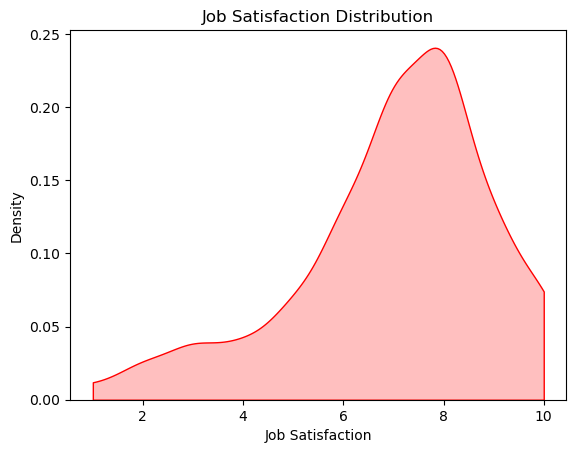

In [8]:
## Write your code here
sns.kdeplot(data=df,
			x="JobSat",
			fill=True,
			color="red",
			bw_adjust=2,
			cut=True,
			clip=(1, 10),
			cumulative=False)
plt.xlabel("Job Satisfaction")
plt.title("Job Satisfaction Distribution");

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


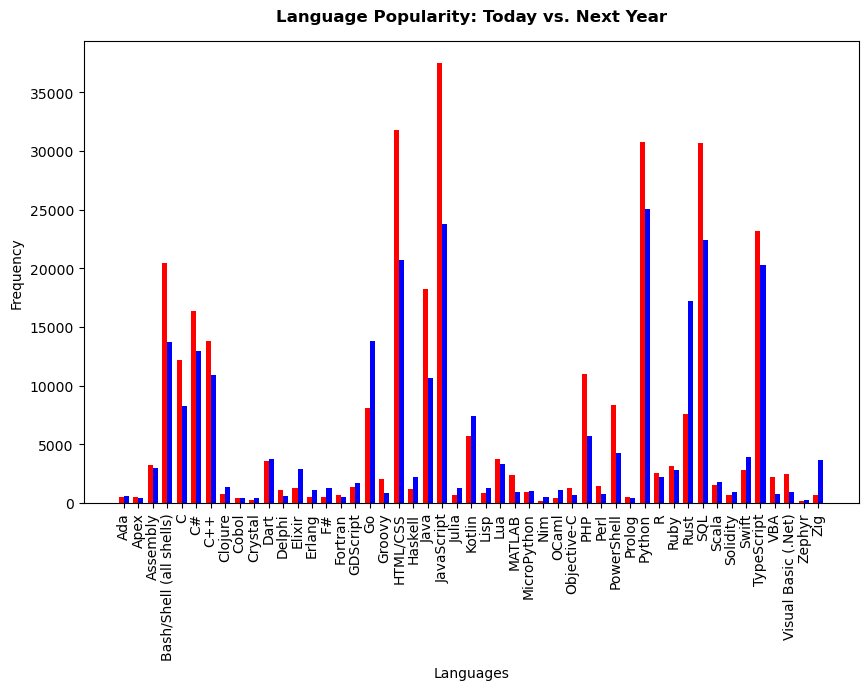

In [9]:
## Write your code here
import numpy as np

s1 = (df
	.assign(lang1=df["LanguageHaveWorkedWith"].str.split(";"))
	.explode("lang1")["lang1"]
	.reset_index())
s2 = (df
	.assign(lang2=df["LanguageWantToWorkWith"].str.split(";"))
	.explode("lang2")["lang2"]
	.reset_index())

df1 = s1.groupby("lang1").size()
df2 = s2.groupby("lang2").size()

df_new = pd.concat([df1, df2], axis=1, ignore_index=False).reset_index()
df_new.columns = ["Languages", "HaveWorkedWith", "WantToWorkWith"]

fig, ax = plt.subplots(figsize=(10,6))
width=0.35
tick_count = np.arange(df_new.shape[0])
ax.bar(x=width + tick_count, width=width, height=df_new.HaveWorkedWith, color="red", label="Today")
ax.bar(x=width * 2 + tick_count, width=width, height=df_new.WantToWorkWith, color="blue", label="Next Year")
plt.xlabel("Languages")
plt.ylabel("Frequency")
plt.title("Language Popularity: Today vs. Next Year", fontweight="bold", y=1.025)
plt.xticks(ticks= tick_count + width * 1.5, rotation=90, labels=df_new.Languages);

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


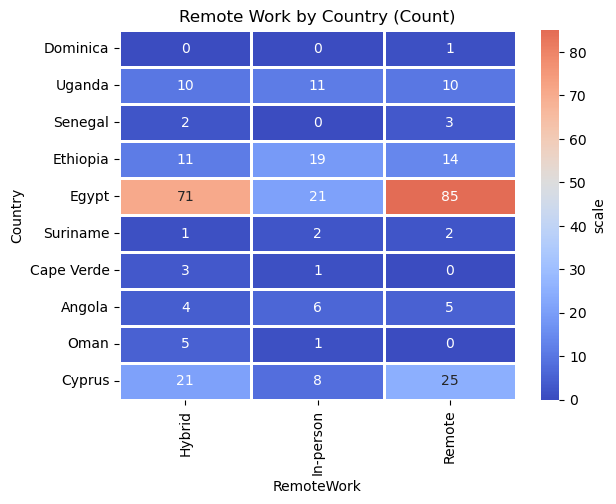

In [10]:
## Write your code here
cross_table = pd.crosstab(index=df.Country, columns=df.RemoteWork)
cross_table
sns.heatmap(data=cross_table.sample(10),
			ec="0.0",
			lw=1,
			center=50,
			annot=True,
			fmt=".0f",
			cmap="coolwarm",
			snap=True,
			cbar_kws={"label":"scale"})
plt.xticks(ticks=[0.5, 1.5, 2.5], labels=["Hybrid", "In-person", "Remote"])
plt.title("Remote Work by Country (Count)");

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [11]:
## Write your code here
from scipy import stats

df.JobSat = df.JobSat.ffill().bfill().astype("Int64")

df.YearsCodePro.value_counts()
df.YearsCodePro = df.YearsCodePro.replace({"Less than 1 year":1, "More than 50 years":50})
df.YearsCodePro.value_counts()
df.YearsCodePro = df.YearsCodePro.ffill().bfill()
df.YearsCodePro = pd.to_numeric(df.YearsCodePro, downcast="integer")

r, p = stats.pearsonr(df.JobSat, df.YearsCodePro)
print("%.2f%%, %.2f"%(r*100, p))

6.39%, 0.00


### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


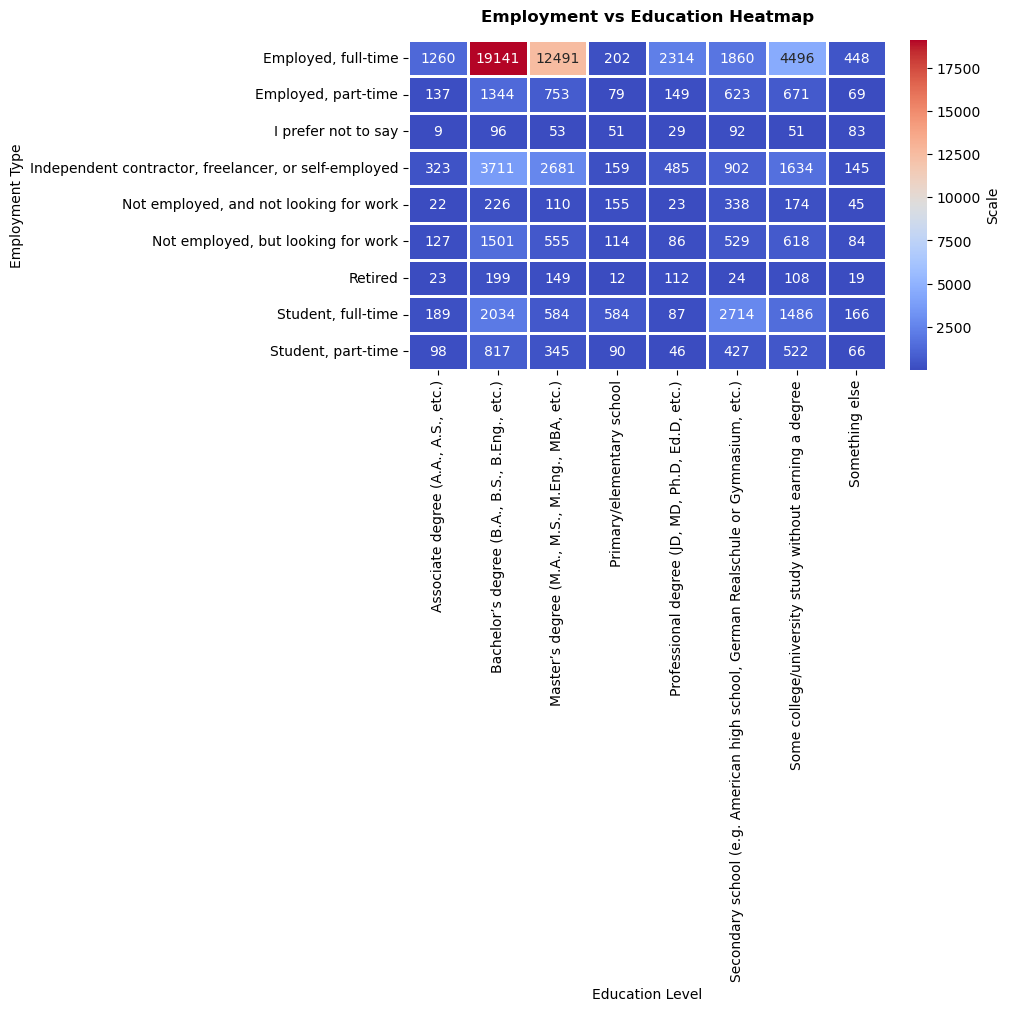

In [12]:
## Write your code here
df_exploded = (df
	.assign(Emp=df.Employment.str.split(";"))
	.explode("Emp"))
df_exploded = df_exploded.iloc[:, 4:]

df_group=(df_exploded
	.groupby(["Emp", "EdLevel"])
	.size()
	.reset_index(name="Count"))

df_pivot = df_group.pivot(index="Emp", columns="EdLevel", values="Count")

fig, ax = plt.subplots(figsize=(10, 10), layout="constrained")
sns.heatmap(data=df_pivot,
			# mask=df_pivot > 5000,
			# center=500,
			annot=True,
			fmt=".0f",
			ec="0.0",
			lw=1,
			snap=True,
			cmap="coolwarm",
			cbar_kws={"label":"Scale"},
		    ax=ax)

plt.ylabel("Employment Type")
plt.xlabel("Education Level")
plt.title("Employment vs Education Heatmap", fontweight=650, y=1.03)
fig.savefig("Emp.Edlevel.png");

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
